# Projet Puls_Events

In [1]:
import pandas as pd

# Chargement des sources
fichier_source = "Data/evenements-publics-openagenda.csv"


for bloc in pd.read_csv(
    fichier_source,
    sep=";",
    chunksize=10_000,
    encoding="utf-8"
):
    display(bloc.head())
    print(bloc.columns.tolist())
    break



,Identifiant,Slug,URL canonique,Titre,Description,Description longue,Détail des conditions,Mots clés,Image,Crédits image,...,Agenda d'origine (uid),Contributeur: Email,Contributeur: Téléphone,Contributeur: Nom,Contributeur: Fonction,Contributeur: organisation,Catégorie,Nom du pays,Registration,Liens additionnels
0,12413663,centre-social-st-rambert-dalbon-5148959,https://openagenda.com/tootsweet/events/centre...,Centre social St Rambert d'Albon,organisé par Centre social St Rambert d'Albon,"<p>Atelier de danses ""Folk""</p>\n<p></p>\n<p>A...",Gratuit,"breton,bretone,danse,atelier,26",NaN,NaN,...,82566953.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,75551745,coupe-de-normandie-vtt-25-septembre-2021,https://openagenda.com/tootsweet/events/coupe-...,Coupe de Normandie VTT - 25 septembre 2021 - F...,Coupe de Normandie et Trophée Régional des Jeu...,<p>L'association Vélo Jeunes Aventure organise...,pass sanitaire obligatoire,"sport,vtt,feuguerolles bully,calvados",https://cibul.s3.amazonaws.com/60a782a88d1e433...,NaN,...,94552197.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""link"", ""value"": ""http://www.normand...",NaN
2,87153658,un-deux-trad-invite-les-tralala-lovers-8266071,https://openagenda.com/tootsweet/events/un-deu...,"Un, deux, trad invite les Tralala Lovers",avec Tralala Lovers et Viendez-Voir,"<p>Le ""fameux"" bal de Mirecourt est enfin de r...",10€,"baltrad,balfolk,danse,chant,musique,88",https://cibul.s3.amazonaws.com/07ad84a33c24458...,NaN,...,82566953.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[{""data"": {""author_url"": ""https://www.youtube...."
3,35021962,totalement-90-6588587,https://openagenda.com/tootsweet/events/totale...,Totalement 90,"WORLDS APART, LARUSSO, INDRA, BORIS, YANNICK E...",<p>Totalement 90 accueillera le chanteur Boris...,Tarifs: de 35€ à 45€,"chanson,spectacle,show,Longjumeau,Essonne,Ile ...",https://cibul.s3.amazonaws.com/9f486cc452114f1...,NaN,...,15004001.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""phone"", ""value"": ""01 69 09 09 09""}]",NaN
4,71691788,atelier-signer-avec-bebe-avec-laure-giry,https://openagenda.com/issy-com/events/atelier...,Atelier « Signer avec bébé » avec Laure Giry,"Séance N°1 sur 2, pour découvrir la communicat...",NaN,Sur réservation auprès d’A3N,"signer,bébé,gestuelle bébé,communication avec ...",https://cibul.s3.amazonaws.com/event_atelier-s...,NaN,...,80515007.0,NaN,NaN,NaN,NaN,NaN,NaN,France (Métropole),"[{""type"": ""phone"", ""value"": ""06 81 91 43 44""},...",NaN


['Identifiant', 'Slug', 'URL canonique', 'Titre', 'Description', 'Description longue', 'Détail des conditions', 'Mots clés', 'Image', 'Crédits image', 'Aperçu', 'Image source', 'Dernière mise à jour', 'Résumé horaires', 'Première date - Début', 'Première date - Fin', 'Dernière date - Début', 'Dernière date - Fin', 'Horaires détaillés', "Code d'accessibilité", 'Accessibilité', 'Identifiant du lieu', 'Coordonnées géographiques', 'Nom du lieu', 'Adresse', 'Arrondissement', 'Code INSEE', 'Code postal', 'Ville', 'Département', 'Région', 'Pays', 'Image du lieu', "Crédits de l'image du lieu", 'Téléphone du lieu', 'Site web du lieu', 'Liens du lieu', 'Tags du lieu', 'Description du lieu', 'Accès / Itinéraire', 'Événement physique ou en ligne', "Lien d'accès en ligne", "État de l'événement", 'Age minimum', 'Age maximum', "Agenda d'origine (titre)", "Agenda d'origine (uid)", 'Contributeur: Email', 'Contributeur: Téléphone', 'Contributeur: Nom', 'Contributeur: Fonction', 'Contributeur: organisati

In [2]:
# conversion en fichiers parquet
for i, bloc in enumerate(pd.read_csv(fichier_source,  sep=";", chunksize=100_000)):
    bloc.to_parquet(f"data/parquet_sortie/part-{i:04d}.parquet", index=False)

In [3]:
# Analyse du fichier parquet
df = pd.read_parquet("data/parquet_sortie/part-0000.parquet")
df.describe()

,Identifiant,Identifiant du lieu,Age minimum,Age maximum,Agenda d'origine (uid),Contributeur: Email,Contributeur: Téléphone,Contributeur: Nom,Contributeur: Fonction,Contributeur: organisation,Catégorie
count,1.000000e+05,9.977200e+04,16093.000000,22098.000000,9.923400e+04,0.0,0.0,0.0,0.0,0.0,0.0
mean,4.995233e+07,5.026781e+07,9.558069,79.788216,3.974640e+07,NaN,NaN,NaN,NaN,NaN,NaN
std,2.882509e+07,2.882240e+07,6.492012,37.267035,2.926612e+07,NaN,NaN,NaN,NaN,NaN,NaN
min,1.225000e+03,2.700000e+03,1.000000,1.000000,5.746000e+03,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.496990e+07,2.519298e+07,6.000000,80.000000,9.977986e+06,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.993728e+07,5.031024e+07,8.000000,99.000000,3.849588e+07,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.486513e+07,7.526018e+07,12.000000,99.000000,6.192520e+07,NaN,NaN,NaN,NaN,NaN,NaN
max,9.999874e+07,9.999928e+07,75.000000,121.000000,9.995489e+07,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Filtre sur la région et la date

#print(bloc.columns.tolist())
df_filtre = df[
    (df["Région"] == "Bretagne") &
    (df["Dernière date - Début"] >= "2025-08-01")
].copy()

df_filtre.to_parquet("data/parquet_sortie/part-0000-filtre.parquet", index=False)

# Suppression des identifiants
df_filtre = df_filtre.drop(columns=[df_filtre.columns[0], df_filtre.columns[21]]).copy()

df_filtre.head()
df_filtre.info()

<class 'pandas.DataFrame'>
Index: 1050 entries, 2130 to 98848
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Slug                            1050 non-null   str    
 1   URL canonique                   1050 non-null   str    
 2   Titre                           1039 non-null   str    
 3   Description                     1039 non-null   str    
 4   Description longue              936 non-null    str    
 5   Détail des conditions           625 non-null    str    
 6   Mots clés                       520 non-null    str    
 7   Image                           968 non-null    str    
 8   Crédits image                   558 non-null    str    
 9   Aperçu                          968 non-null    str    
 10  Image source                    968 non-null    str    
 11  Dernière mise à jour            1050 non-null   str    
 12  Résumé horaires                 1050 non-null 

In [12]:
print(df_filtre.dtypes)

Slug                                  str
URL canonique                         str
Titre                                 str
Description                           str
Description longue                    str
Détail des conditions                 str
Mots clés                             str
Image                                 str
Crédits image                         str
Aperçu                                str
Image source                          str
Dernière mise à jour                  str
Résumé horaires                       str
Première date - Début                 str
Première date - Fin                   str
Dernière date - Début                 str
Dernière date - Fin                   str
Horaires détaillés                    str
Code d'accessibilité                  str
Accessibilité                         str
Coordonnées géographiques             str
Nom du lieu                           str
Adresse                               str
Arrondissement                    

In [14]:
df_filtre.count()

Slug                              1050
URL canonique                     1050
Titre                             1039
Description                       1039
Description longue                 936
Détail des conditions              625
Mots clés                          520
Image                              968
Crédits image                      558
Aperçu                             968
Image source                       968
Dernière mise à jour              1050
Résumé horaires                   1050
Première date - Début             1050
Première date - Fin               1050
Dernière date - Début             1050
Dernière date - Fin               1050
Horaires détaillés                1050
Code d'accessibilité               196
Accessibilité                      196
Coordonnées géographiques         1050
Nom du lieu                       1050
Adresse                           1050
Arrondissement                     565
Code INSEE                        1007
Code postal              

In [13]:
# Tests unitaires
df_test = pd.read_parquet("data/parquet_sortie/part-0000-filtre.parquet")
print(df_test.head())
print(df_test.shape)
print("Régions filtrées : "+ df_test["Région"].unique())

# Vérification : True si toutes les dates respectent la condition
controle = (df_test["Dernière date - Début"] >= "2025-08-01").all()
print("Contrôle de date : "+ str(controle))

   Identifiant                               Slug  \
0     25285630           manoir-de-la-goeletterie   
1     51542232  diwali-fete-de-la-lumiere-9555742   
2     16590527           sejour-changez-dair-2026   
3     81916333                don-de-sang-9772205   
4     18729227   the-retro-market-vintage-4006413   

                                       URL canonique  \
0  https://openagenda.com/catalogue-structures-ac...   
1  https://openagenda.com/sortir-rennesmetropole/...   
2  https://openagenda.com/sortir-rennesmetropole/...   
3  https://openagenda.com/saint-sulpice-la-foret/...   
4  https://openagenda.com/sortir-rennesmetropole/...   

                         Titre  \
0     Manoir de la Goëletterie   
1  Diwali - Fête de la lumière   
2    Séjour Changez d'Air 2026   
3                  Don de sang   
4     The Retro Market Vintage   

                                         Description  \
0  Etablissement d'accueil et d'hébergement d'élè...   
1  Venez en famille avec le

# Génération des embeddings

In [18]:
import os
from pathlib import Path
import numpy as np

from dotenv import load_dotenv
from mistralai.client import Mistral

from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

load_dotenv(".env")

load_dotenv(Path.cwd() / "mistralKey.env")
api_key = os.environ["MISTRAL_API_KEY"]

# Colonnes utiles à la recherche sémantique
colonnes_embedding = [
    "Titre",
    "Description",
    "Description longue",
    "Mots clés",
    "Ville",
    "Région",
]

# Une ligne DataFrame devient un document texte
documents = (
    df_filtre[colonnes_embedding]
    .fillna("")
    .astype(str)
    .apply(
        lambda ligne: "\n".join(
            f"{colonne}: {valeur.strip()}"
            for colonne, valeur in ligne.items()
            if valeur.strip()
        ),
        axis=1,
    )
)

# Écarte les éventuels documents vides tout en gardant leurs index
mask = documents.str.strip().ne("")
df_embeddings = df_filtre.loc[mask].copy()
documents = documents.loc[mask].tolist()

# Appels en lots pour traiter les 1 050 événements proprement
taille_lot = 100
embeddings = []

with Mistral(api_key=api_key) as mistral:
    for debut in range(0, len(documents), taille_lot):
        lot = documents[debut:debut + taille_lot]

        reponse = mistral.embeddings.create(
            model="mistral-embed",
            inputs=lot,
        )

        embeddings.extend(
            item.embedding
            for item in sorted(
                reponse.data, 
                key=lambda item: item.index if item.index is not None else -1,)
        )

# Conserve le texte envoyé et son vecteur sur chaque événement
df_embeddings["texte_embedding"] = documents
df_embeddings["embedding"] = embeddings

df_embeddings.to_parquet(
    "data/parquet_sortie/evenements_embeddings_mistral.parquet",
    index=False,
)

print(f"{len(df_embeddings)} embeddings créés.")
print(f"Dimension d'un embedding : {len(embeddings[0])}")

1050 embeddings créés.
Dimension d'un embedding : 1024


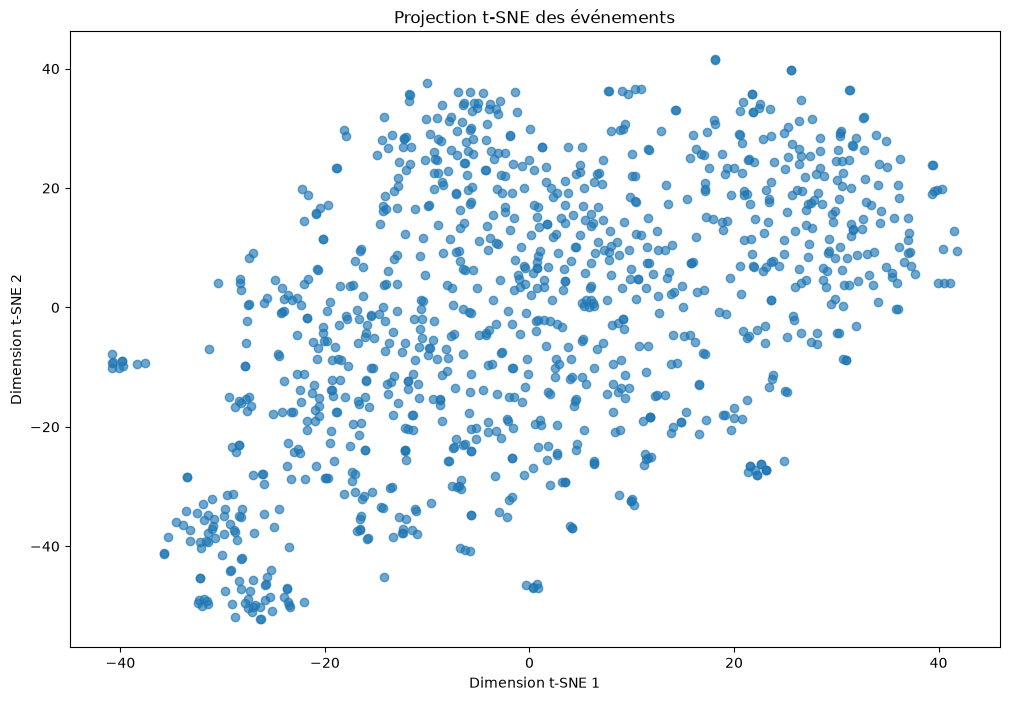

In [19]:
# Réduction de dimension pour les embeddings Mistral

# Conversion de la colonne contenant les vecteurs Mistral en matrice NumPy
matrice_embeddings = np.asarray(df_embeddings["embedding"].tolist())

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1_000,
    random_state=42,
)

embeddings_2d = tsne.fit_transform(matrice_embeddings)

df_embeddings["tsne_x"] = embeddings_2d[:, 0]
df_embeddings["tsne_y"] = embeddings_2d[:, 1]

plt.figure(figsize=(12, 8))
plt.scatter(
    df_embeddings["tsne_x"],
    df_embeddings["tsne_y"],
    alpha=0.65,
)

plt.title("Projection t-SNE des événements")
plt.xlabel("Dimension t-SNE 1")
plt.ylabel("Dimension t-SNE 2")
plt.show()